Program 1

## Word Count and File Processing using Hadoop MapReduce

In [1]:
from functools import reduce 
import re  
def map_func(wc):     
    with open(file_name, 'r') as file:  
       lines = file.readlines()  
       words = [word.strip() for line in lines for word in line.split()]         
    return words  
def reduce_func(words):  
    word_count = {}  
    for word in words:         
      if word in word_count:             
         word_count[word] += 1         
      else:  
        word_count[word] = 1  
    return word_count  
def word_count(wc):  
    words = map_func(file_name)     
    word_count = reduce_func(words)     
    return word_count  
file_name = 'wc.txt'  
word_count_result = word_count(file_name)   
print("Word count:") 
for word, count in word_count_result.items():  
   print(f"{word}: {count}")


Word count:
My: 1
name: 1
is: 1
Sai: 1
Vamsi.: 1
Iam: 1
studing: 1
in: 1
AITS.: 1


Program 2

## Working with Hive: Table creation, loading data, and performing analytical queries

In [1]:
pip install numpy

Note: you may need to restart the kernel to use updated packages.


c:\Users\saiva\AppData\Local\Programs\Python\Python313\python.exe: No module named pip


In [3]:
import pandas as pd


df = pd.read_csv("students.csv")

print("Full Table:")
print(df)

print("\nStudents with marks > 70:")
print(df[df["marks"] > 70])

Full Table:
   id       name  age  marks branch  result
0   1       Raju   20     65    CSE       0
1   2  Lakshitha   21     92    CSE       1
2   3       Amit   22     78    ECE       1
3   4      Sneha   21     55    EEE       0
4   5      Rohit   23     85    CSE       1

Students with marks > 70:
   id       name  age  marks branch  result
1   2  Lakshitha   21     92    CSE       1
2   3       Amit   22     78    ECE       1
4   5      Rohit   23     85    CSE       1


Program 3

In [4]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("test").getOrCreate()
print("Spark running successfully!")


Spark running successfully!


## Data cleaning and transformation using PySpark DataFrames

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, avg, max as mx, min as mn

def create_spark_session():
    spark = SparkSession.builder.appName("BigDataCleaning").getOrCreate()
    return spark

def load_data(spark):
    df = spark.read.csv("data.csv", header=True, inferSchema=True)
    return df

def explore_data(df):
    df.show()
    df.printSchema()
    df.describe().show()

def clean_data(df):
    df = df.withColumn("marks", when(col("marks").isNull(), 0).otherwise(col("marks")))
    avg_age = df.select(avg("age")).first()[0]
    df = df.withColumn("age", when(col("age").isNull(), avg_age).otherwise(col("age")))
    df.show()
    return df

def transform_data(df):
    df = df.withColumn("marks", col("marks") + 5)
    df = df.withColumn(
        "grade",
        when(col("marks") >= 90, "A")
        .when(col("marks") >= 75, "B")
        .otherwise("C")
    )
    df.show()
    return df
def analyze_data(df):
    df.select(
        mx("marks").alias("MaxMarks"),
        mn("marks").alias("MinMarks"),
        avg("marks").alias("AvgMarks")
    ).show()
def main():
    spark = create_spark_session()
    df = load_data(spark)
    explore_data(df)
    df = clean_data(df)
    df = transform_data(df)
    analyze_data(df)
    spark.stop()
if __name__ == "__main__":
    main()


+----+----+-----+
|name| age|marks|
+----+----+-----+
|   A|  20|   80|
|   B|NULL|   90|
|   C|  22| NULL|
|   D|  21|   70|
+----+----+-----+

root
 |-- name: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- marks: integer (nullable = true)

+-------+----+----+-----+
|summary|name| age|marks|
+-------+----+----+-----+
|  count|   4|   3|    3|
|   mean|NULL|21.0| 80.0|
| stddev|NULL| 1.0| 10.0|
|    min|   A|  20|   70|
|    max|   D|  22|   90|
+-------+----+----+-----+

+----+----+-----+
|name| age|marks|
+----+----+-----+
|   A|20.0|   80|
|   B|21.0|   90|
|   C|22.0|    0|
|   D|21.0|   70|
+----+----+-----+

+----+----+-----+-----+
|name| age|marks|grade|
+----+----+-----+-----+
|   A|20.0|   85|    B|
|   B|21.0|   95|    A|
|   C|22.0|    5|    C|
|   D|21.0|   75|    B|
+----+----+-----+-----+

+--------+--------+--------+
|MaxMarks|MinMarks|AvgMarks|
+--------+--------+--------+
|      95|       5|    65.0|
+--------+--------+--------+



Program 4

## Visualizing data using Matplotlib and Seaborn for univariate and bivariate analysis

  month  sales country  year
0   Jan    100   India  2023
1   Feb    120     USA  2023
2   Mar    150   India  2023
3   Apr    180     USA  2024
4   May    200   India  2024
            sales         year
count    5.000000     5.000000
mean   150.000000  2023.400000
std     41.231056     0.547723
min    100.000000  2023.000000
25%    120.000000  2023.000000
50%    150.000000  2023.000000
75%    180.000000  2024.000000
max    200.000000  2024.000000
Max: 200
Min: 100
Avg: 150.0


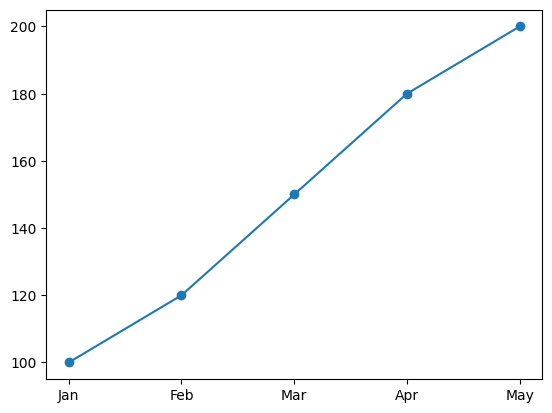

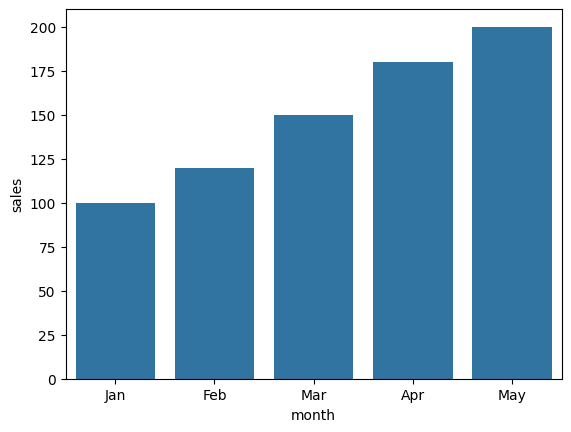

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_data():
    df = pd.read_csv("sales.csv")
    print(df)
    return df

def analyze_data(df):
    print(df.describe())
    print("Max:", df["sales"].max())
    print("Min:", df["sales"].min())
    print("Avg:", df["sales"].mean())

def line_plot(df):
    plt.figure()
    plt.plot(df["month"], df["sales"], marker="o")
    plt.show()

def bar_plot(df):
    plt.figure()
    sns.barplot(x="month", y="sales", data=df)
    plt.show()

def main():
    df = load_data()
    analyze_data(df)
    line_plot(df)
    bar_plot(df)

if __name__ == "__main__":
    main()


Program 5

## Creating interactive plots using Plotly and Dash

In [1]:
import pandas as pd
import dash
from dash import dcc, html
import plotly.express as px
def load_data():
    print("Reading sales data from file...")
    df = pd.read_csv("sales.csv")
    print(df)
    return df
def analyze_data(df):
    print("Basic statistics:")
    print(df.describe())
    print("Finding max and min sales:")
    print("Max Sales:", df["sales"].max())
    print("Min Sales:", df["sales"].min())
def create_plot(df):
    fig = px.line(df, x="month", y="sales", markers=True, title="Monthly Sales Analysis")
    return fig
def create_app(fig):
    app = dash.Dash(__name__)

    app.layout = html.Div([
        html.H1("Sales Dashboard", style={"textAlign": "center"}),
        html.P("This dashboard shows monthly sales analysis."),
        dcc.Graph(figure=fig)
    ])
    return app
def main():
    df = load_data()
    analyze_data(df)
    fig = create_plot(df)
    app = create_app(fig)
    app.run(debug=True)
if __name__ == "__main__":
    main()

Reading sales data from file...
  month  sales country  year
0   Jan    100   India  2023
1   Feb    120     USA  2023
2   Mar    150   India  2023
3   Apr    180     USA  2024
4   May    200   India  2024
Basic statistics:
            sales         year
count    5.000000     5.000000
mean   150.000000  2023.400000
std     41.231056     0.547723
min    100.000000  2023.000000
25%    120.000000  2023.000000
50%    150.000000  2023.000000
75%    180.000000  2024.000000
max    200.000000  2024.000000
Finding max and min sales:
Max Sales: 200
Min Sales: 100


Program 6


## Exploratory Data Analysis (EDA) and feature analysis with Pandas and Seaborn

In [12]:
import pandas as pd

def load_data():
    print("Loading student dataset...")
    df = pd.read_csv("students.csv")
    print(df)
    return df

def basic_info(df):
    print("\n=== First 5 Rows ===")
    print(df.head())

    print("\n=== Last 5 Rows ===")
    print(df.tail())

    print("\n=== Dataset Info ===")
    print(df.info())

def statistical_analysis(df):
    print("\n=== Statistical Summary ===")
    print(df.describe())

    print("\nMax Marks:", df["marks"].max())
    print("Min Marks:", df["marks"].min())
    print("Average Marks:", df["marks"].mean())

def null_analysis(df):
    print("\n=== Missing Values ===")
    print(df.isnull().sum())

def group_analysis(df):
    print("\n=== Age-wise Average Marks ===")
    print(df.groupby("age")["marks"].mean())

def main():
    df = load_data()
    basic_info(df)
    statistical_analysis(df)
    null_analysis(df)
    group_analysis(df)
    print("\nEDA Completed Successfully.")

if __name__ == "__main__":
    main()


Loading student dataset...
   id       name  age  marks branch  result
0   1       Raju   20     65    CSE       0
1   2  Lakshitha   21     92    CSE       1
2   3       Amit   22     78    ECE       1
3   4      Sneha   21     55    EEE       0
4   5      Rohit   23     85    CSE       1

=== First 5 Rows ===
   id       name  age  marks branch  result
0   1       Raju   20     65    CSE       0
1   2  Lakshitha   21     92    CSE       1
2   3       Amit   22     78    ECE       1
3   4      Sneha   21     55    EEE       0
4   5      Rohit   23     85    CSE       1

=== Last 5 Rows ===
   id       name  age  marks branch  result
0   1       Raju   20     65    CSE       0
1   2  Lakshitha   21     92    CSE       1
2   3       Amit   22     78    ECE       1
3   4      Sneha   21     55    EEE       0
4   5      Rohit   23     85    CSE       1

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column  Non